In [2]:
import random
import json
import os
import re
import warnings
from datetime import datetime
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import nltk
nltk.download('stopwords', quiet=True)

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

train = pd.read_csv('../data/raw/penyisihan-dac-ifest-2026/train.csv')
test = pd.read_csv('../data/raw/penyisihan-dac-ifest-2026/test.csv')
print(f"Train shape: {train.shape}, Test shape: {test.shape}")
train.head()

Train shape: (14400, 4), Test shape: (3600, 3)


,id,title,content,label
0,1,Ada 70 029 Kasus Suspek Corona Dipantau Per 6 ...,Terdapat puluhan ribu kasus suspek Corona yang...,1
1,2,Suku Bunga Acuan Dipangkas Suku Bunga Kredit K...,Selama masa pandemi Covid 19 Bank Indonesia BI...,1
2,3,Satpol PP Siap Jemput Paksa Pasien Covid 19 To...,Satuan Polisi Pamong Praja Satpol PP DKI Jakar...,1
3,4,Pantau Pencoblosan di TPS Andre Rosiade Sebut ...,Anggota DPR RI Dapil Sumbar 1 Andre Rosiade me...,1
4,5,Vaksin Jadi Harapan Pulihkan Pariwisata dan Bi...,Pelaku usaha sektor pariwisata dan properti me...,1


In [3]:
label_names = {0: 'Tidak Sesuai', 1: 'Sesuai'}

def dataset_inspection(df, name="dataset"):
    print(f"{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"Shape: {df.shape}")
    print(f"\nColumns: {list(df.columns)}")
    print(f"\nDtypes:\n{df.dtypes.to_string()}")
    print(f"\nMissing values:\n{df.isnull().sum().to_string()}")
    for col in df.select_dtypes(include='object').columns:
        empty_count = (df[col].astype(str).str.strip() == '').sum()
        print(f"Empty strings in '{col}': {empty_count}")
    print(f"\nDuplicate rows: {df.duplicated().sum()}")
    print()

dataset_inspection(train, "Train")
dataset_inspection(test, "Test")

# Auto-discover text columns & label
text_cols = [c for c in train.columns if train[c].dtype == 'object' and c != 'id']
label_col = [c for c in train.columns if c not in text_cols and c != 'id'][0]

print(f"Auto-discovered text columns: {text_cols}")
print(f"Auto-discovered label column: {label_col}")

# Map to internal names (verify manually!)
headline_col = text_cols[0]
article_col = text_cols[1]
print(f"Mapped: headline='{headline_col}', article='{article_col}'")
print(f"NOTE: Verify mapping is correct! If swapped, change manually.")

# Labels
print(f"\nUnique labels: {train[label_col].unique()}")
print(f"\nLabel counts:")
print(train[label_col].value_counts().to_string())
print(f"\nLabel proportions:")
print(train[label_col].value_counts(normalize=True).to_string())

  Train
Shape: (14400, 4)

Columns: ['id', 'title', 'content', 'label']

Dtypes:
id          int64
title      object
content    object
label       int64

Missing values:
id         0
title      0
content    0
label      0
Empty strings in 'title': 0
Empty strings in 'content': 0

Duplicate rows: 0

  Test
Shape: (3600, 3)

Columns: ['id', 'title', 'content']

Dtypes:
id          int64
title      object
content    object

Missing values:
id         0
title      0
content    0
Empty strings in 'title': 0
Empty strings in 'content': 0

Duplicate rows: 0

Auto-discovered text columns: ['title', 'content']
Auto-discovered label column: label
Mapped: headline='title', article='content'
NOTE: Verify mapping is correct! If swapped, change manually.

Unique labels: [1 0]

Label counts:
label
1    12960
0     1440

Label proportions:
label
1    0.9
0    0.1


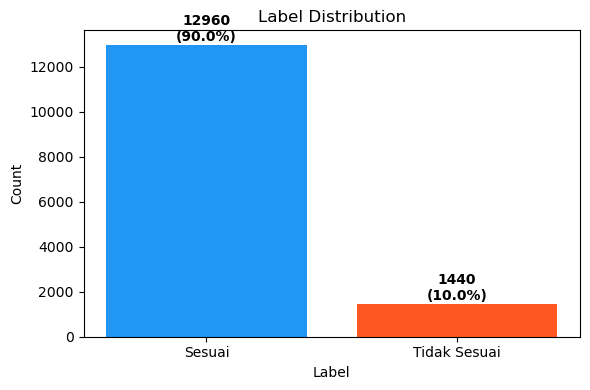


Imbalance ratio: 9.00:1
Majority baseline accuracy: 90.0%
NOTE: Macro F1 is sensitive to imbalance — need balanced class weights or threshold tuning.


In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
label_counts = train[label_col].value_counts()
display_names = [label_names.get(int(l), str(l)) for l in label_counts.index]

bars = ax.bar(display_names, label_counts.values, color=['#2196F3', '#FF5722'])
for bar, count in zip(bars, label_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
            f'{count}\n({count/len(train)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold')
ax.set_title('Label Distribution')
ax.set_xlabel('Label')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

imbalance_ratio = label_counts.max() / label_counts.min()
print(f"\nImbalance ratio: {imbalance_ratio:.2f}:1")
print(f"Majority baseline accuracy: {label_counts.max()/len(train)*100:.1f}%")
print(f"NOTE: Macro F1 is sensitive to imbalance — need balanced class weights or threshold tuning.")

=== Text Length Statistics ===

headline_char_len:
  mean=62.5, median=61.0, min=21, max=150, std=10.7

headline_word_len:
  mean=9.9, median=10.0, min=3, max=23, std=2.0

article_char_len:
  mean=2096.3, median=1864.0, min=204, max=31134, std=1140.1

article_word_len:
  mean=308.3, median=275.0, min=30, max=4238, std=162.1


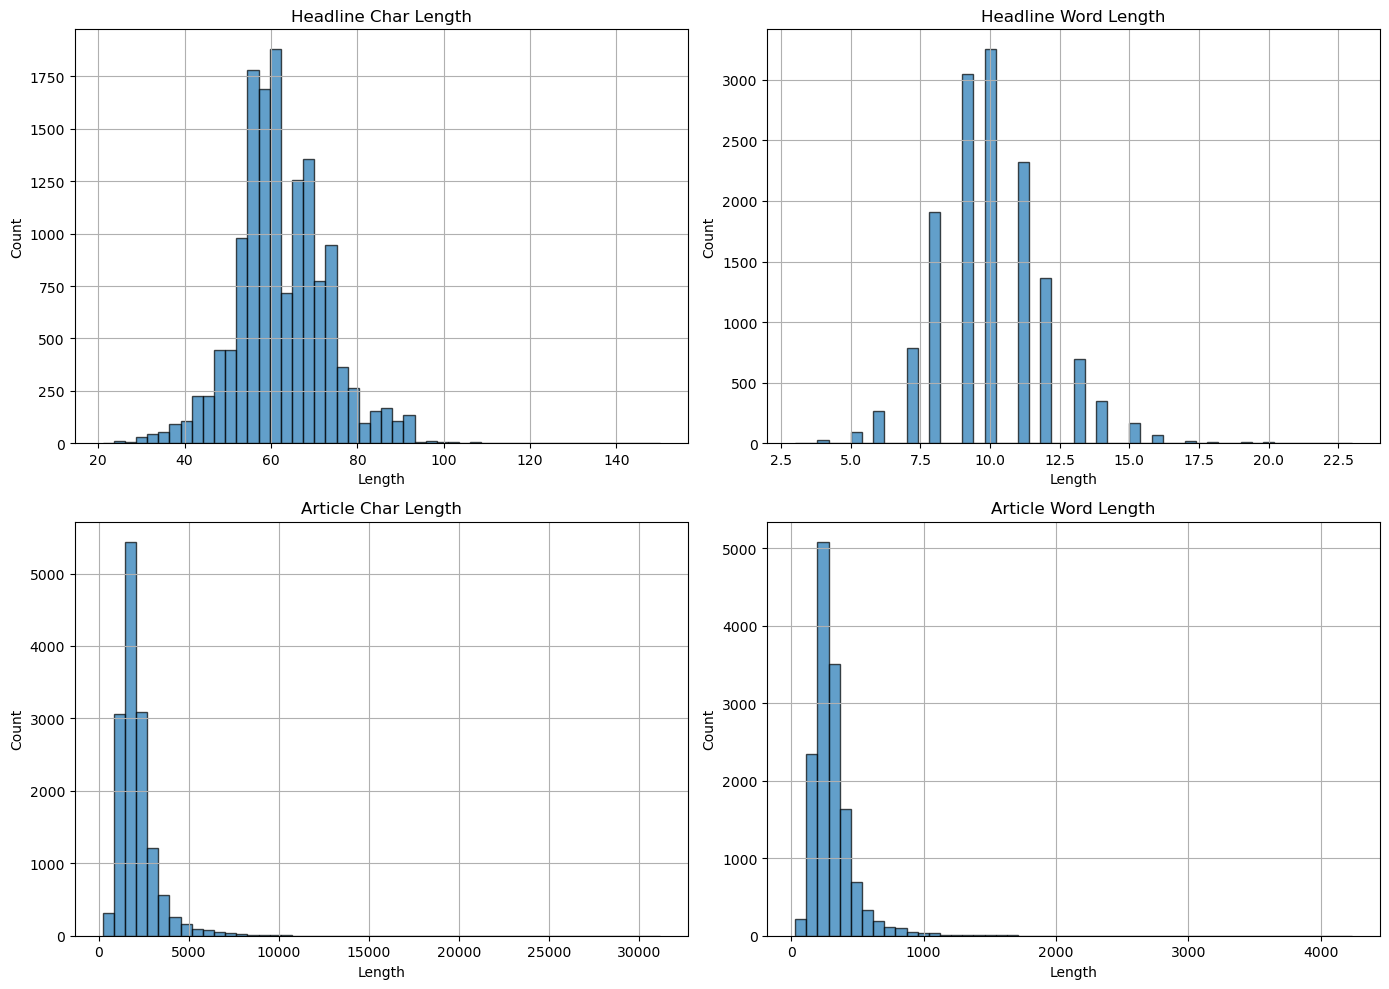

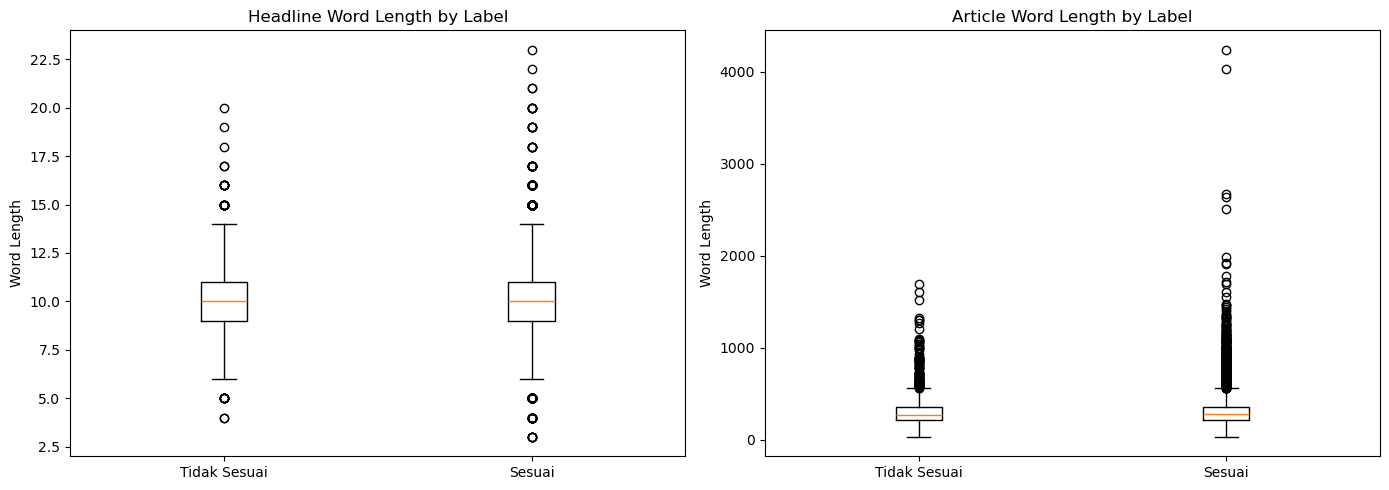


=== Outlier Analysis (IQR Method) ===
headline outliers: 409 (2.84%)
  range: [6.0, 14.0], actual min=3, max=23
  NOTE: Outliers NOT removed — only analyzed. Review before deciding.
article outliers: 781 (5.42%)
  range: [12.5, 560.5], actual min=30, max=4238
  NOTE: Outliers NOT removed — only analyzed. Review before deciding.


In [5]:
def compute_text_lengths(df, col, prefix):
    df = df.copy()
    df[f'{prefix}_char_len'] = df[col].astype(str).str.len()
    df[f'{prefix}_word_len'] = df[col].astype(str).apply(lambda x: len(x.split()))
    return df

train = compute_text_lengths(train, headline_col, 'headline')
train = compute_text_lengths(train, article_col, 'article')

# Statistics
print("=== Text Length Statistics ===")
for metric in ['headline_char_len', 'headline_word_len', 'article_char_len', 'article_word_len']:
    s = train[metric]
    print(f"\n{metric}:")
    print(f"  mean={s.mean():.1f}, median={s.median():.1f}, min={s.min()}, max={s.max()}, std={s.std():.1f}")

# Histograms
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col, title in zip(axes.flat,
    ['headline_char_len', 'headline_word_len', 'article_char_len', 'article_word_len'],
    ['Headline Char Length', 'Headline Word Length', 'Article Char Length', 'Article Word Length']):
    train[col].hist(bins=50, ax=ax, alpha=0.7, edgecolor='black')
    ax.set_title(title)
    ax.set_xlabel('Length')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

# Boxplot by label
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, prefix, title in zip(axes, ['headline', 'article'], ['Headline', 'Article']):
    data_to_plot = [train[train[label_col] == lbl][f'{prefix}_word_len'] for lbl in sorted(train[label_col].unique())]
    ax.boxplot(data_to_plot, labels=[label_names.get(int(l), str(l)) for l in sorted(train[label_col].unique())])
    ax.set_title(f'{title} Word Length by Label')
    ax.set_ylabel('Word Length')
plt.tight_layout()
plt.show()

# Outlier analysis (IQR method)
print("\n=== Outlier Analysis (IQR Method) ===")
for prefix in ['headline', 'article']:
    col = f'{prefix}_word_len'
    q1, q3 = train[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = train[(train[col] < lower) | (train[col] > upper)]
    print(f"{prefix} outliers: {len(outliers)} ({len(outliers)/len(train)*100:.2f}%)")
    print(f"  range: [{lower:.1f}, {upper:.1f}], actual min={train[col].min()}, max={train[col].max()}")
    print(f"  NOTE: Outliers NOT removed — only analyzed. Review before deciding.")

In [6]:
def get_top_ngrams(corpus, n=1, top_k=20):
    vec = CountVectorizer(ngram_range=(n, n), stop_words=None)
    bag_of_words = vec.fit_transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_k]
    return words_freq

# Global top unigrams & bigrams
for n, label_n in [(1, 'unigram'), (2, 'bigram')]:
    print(f"\n{'='*50}")
    print(f"  Top {label_n.upper()} (Global)")
    print(f"{'='*50}")
    for text_col, text_name in [(headline_col, 'Headline'), (article_col, 'Article')]:
        top = get_top_ngrams(train[text_col].astype(str), n=n, top_k=15)
        print(f"\n  {text_name}:")
        for word, freq in top:
            print(f"    {word}: {freq}")

# Per label
for lbl in sorted(train[label_col].unique()):
    subset = train[train[label_col] == lbl]
    lbl_name = label_names.get(int(lbl), str(lbl))
    print(f"\n{'='*50}")
    print(f"  Label: {lbl_name} ({lbl})")
    print(f"{'='*50}")
    for n, label_n in [(1, 'unigram'), (2, 'bigram')]:
        for text_col, text_name in [(headline_col, 'Headline'), (article_col, 'Article')]:
            top = get_top_ngrams(subset[text_col].astype(str), n=n, top_k=10)
            print(f"\n  Top {label_n} ({text_name}):")
            for word, freq in top:
                print(f"    {word}: {freq}")


  Top UNIGRAM (Global)

  Headline:
    di: 4364
    corona: 4257
    covid: 4101
    19: 3275
    positif: 1742
    kasus: 1702
    vaksin: 1168
    dan: 1026
    ini: 905
    tak: 886
    baru: 865
    kumparan: 764
    com: 764
    yang: 742
    ke: 682

  Article:
    yang: 97240
    di: 91064
    dan: 78214
    19: 49033
    covid: 48647
    ini: 47200
    dari: 42675
    untuk: 39686
    itu: 36961
    dengan: 35482
    kasus: 32060
    dalam: 30447
    pada: 27433
    corona: 24626
    ada: 24574

  Top BIGRAM (Global)

  Headline:
    covid 19: 3204
    positif covid: 778
    kumparan com: 764
    positif corona: 667
    corona di: 566
    19 di: 463
    vaksin corona: 427
    kasus corona: 386
    vaksin covid: 331
    kasus covid: 310
    virus corona: 272
    habib rizieq: 257
    pasien covid: 231
    update corona: 228
    tahun baru: 227

  Article:
    covid 19: 46456
    virus corona: 12281
    protokol kesehatan: 7584
    saat ini: 7198
    19 di: 6425
    positif cov

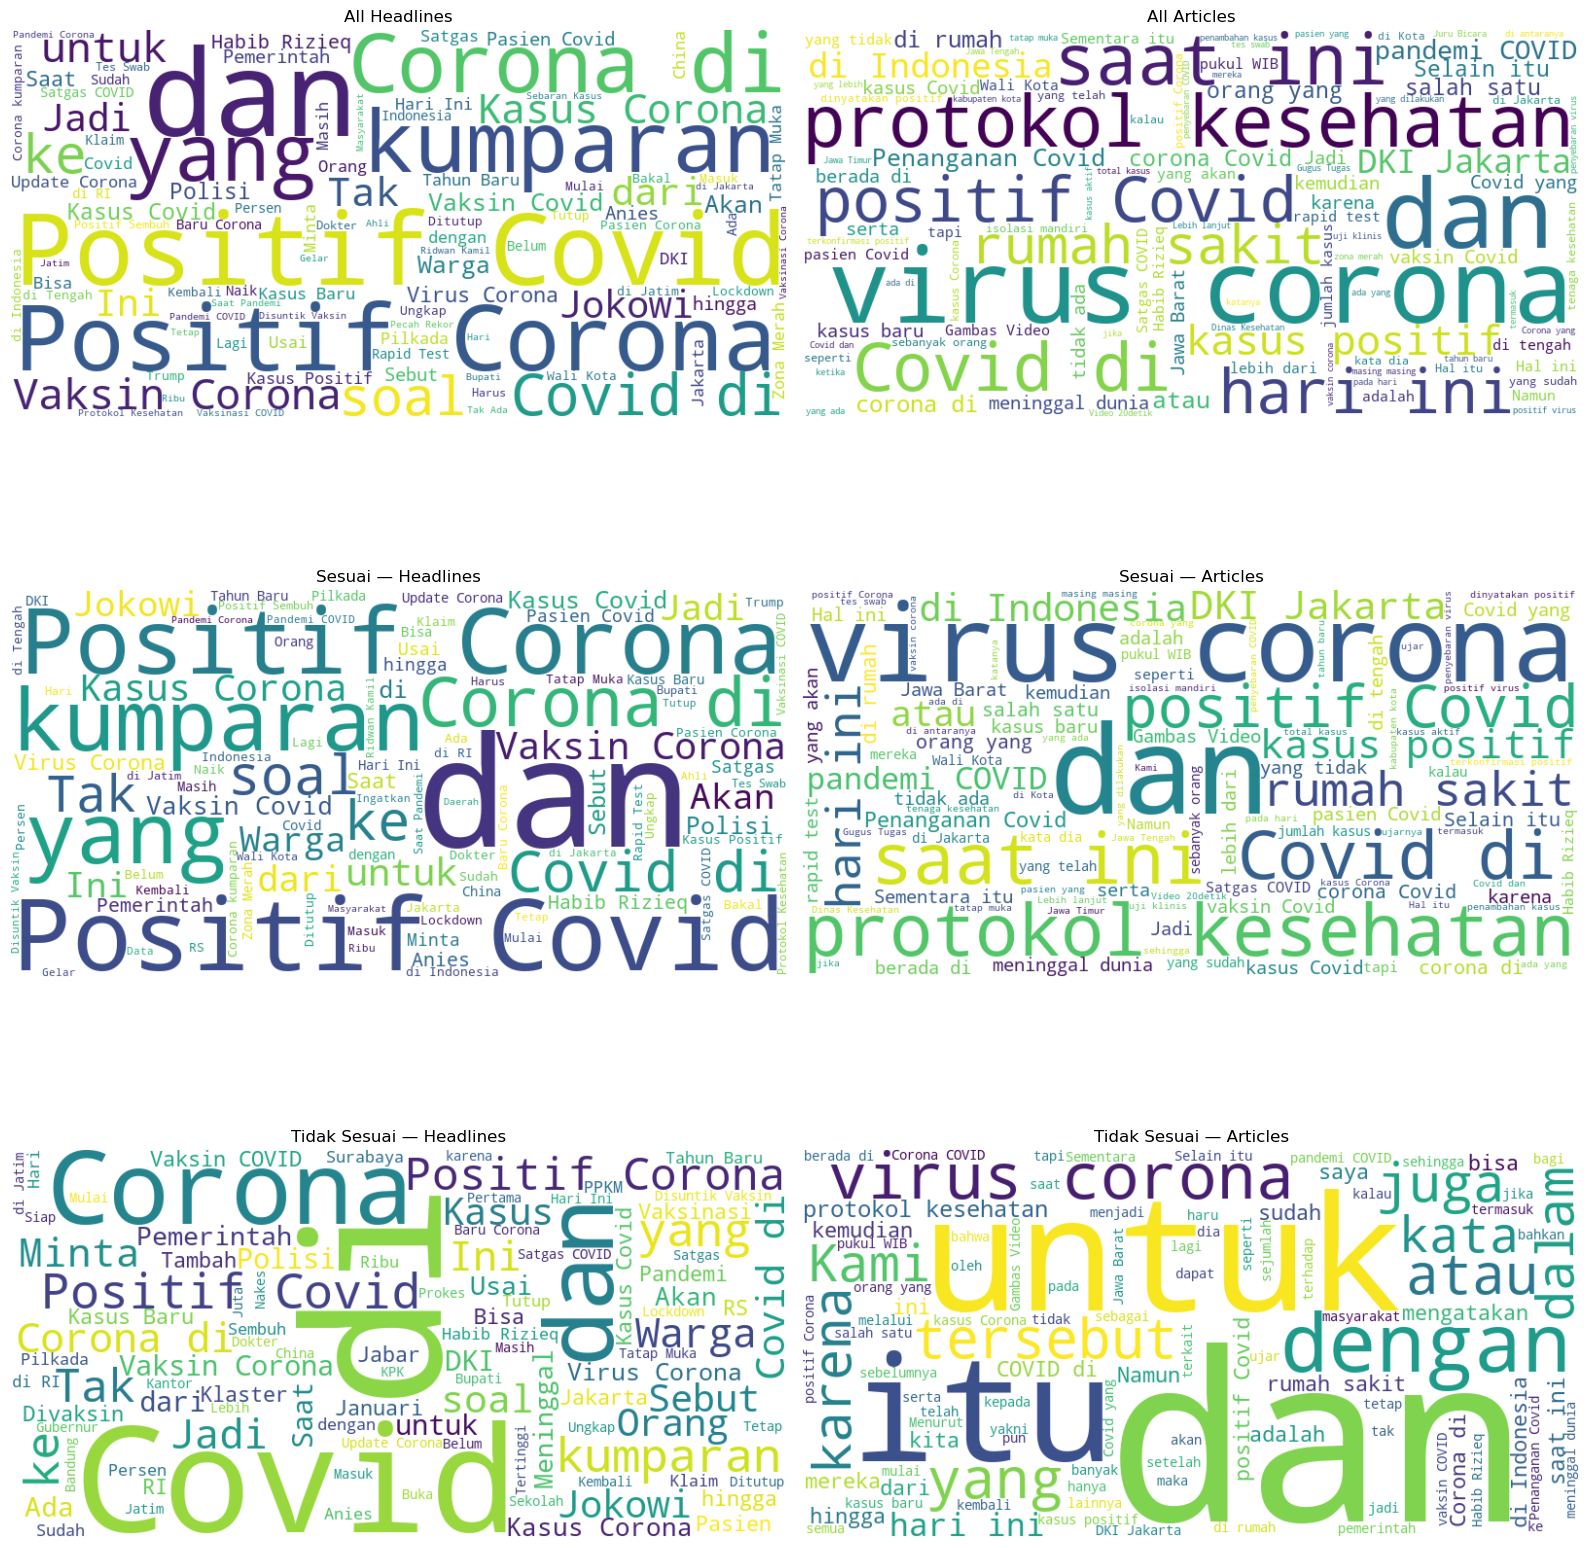

In [7]:
def create_wordcloud(corpus, title, ax):
    text = ' '.join(corpus.astype(str).tolist())
    wc = WordCloud(width=800, height=400, background_color='white',
                   max_words=100, colormap='viridis').generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=12)
    ax.axis('off')

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
corpora = [
    (train[headline_col], 'All Headlines'),
    (train[article_col], 'All Articles'),
    (train[train[label_col]==1][headline_col], 'Sesuai — Headlines'),
    (train[train[label_col]==1][article_col], 'Sesuai — Articles'),
    (train[train[label_col]==0][headline_col], 'Tidak Sesuai — Headlines'),
    (train[train[label_col]==0][article_col], 'Tidak Sesuai — Articles'),
]
for ax, (corpus, title) in zip(axes.flat, corpora):
    create_wordcloud(corpus, title, ax)
plt.tight_layout()
plt.show()

In [8]:
def log_step(step_name, df, col, affected_mask=None):
    if affected_mask is not None:
        n_affected = affected_mask.sum()
        print(f"  [{step_name}] {col}: {n_affected} rows affected ({n_affected/len(df)*100:.2f}%)")
    else:
        print(f"  [{step_name}] {col}: applied to all rows")

def normalize_whitespace(text):
    return re.sub(r'\s+', ' ', str(text)).strip()

def remove_url(text):
    return re.sub(r'https?://\S+|www\.\S+', '', str(text))

def remove_html(text):
    return re.sub(r'<[^>]+>', '', str(text))

def remove_noise(text):
    text = re.sub(r'\S+@\S+', '', str(text))
    text = re.sub(r'[^\w\s.,;:!?%$()\-/+]', '', text)
    return text

def lowercase(text):
    return str(text).lower()

# --- Variant A: Light Cleaning ---
print("=== Variant A: Light Cleaning ===")
for col in [headline_col, article_col]:
    print(f"\n  Processing: {col}")

    mask = train[col].astype(str).apply(lambda x: bool(re.search(r'\s{2,}', str(x))))
    train[f'{col}_clean_a'] = train[col].apply(normalize_whitespace)
    log_step('normalize_whitespace', train, col, mask)

    mask = train[f'{col}_clean_a'].astype(str).apply(lambda x: bool(re.search(r'https?://|www\.', str(x))))
    train[f'{col}_clean_a'] = train[f'{col}_clean_a'].apply(remove_url)
    log_step('remove_url', train, col, mask)

    mask = train[f'{col}_clean_a'].astype(str).apply(lambda x: bool(re.search(r'<[^>]+>', str(x))))
    train[f'{col}_clean_a'] = train[f'{col}_clean_a'].apply(remove_html)
    log_step('remove_html', train, col, mask)

    mask = train[f'{col}_clean_a'].astype(str).apply(lambda x: bool(re.search(r'\S+@|<|>', str(x))))
    train[f'{col}_clean_a'] = train[f'{col}_clean_a'].apply(remove_noise)
    log_step('remove_noise', train, col, mask)

# --- Variant B: Normalized (light + lowercase + stopword) ---
print("\n=== Variant B: Normalized ===")
for col in [headline_col, article_col]:
    print(f"\n  Processing: {col}")

    train[f'{col}_clean_b'] = train[f'{col}_clean_a'].apply(lowercase)
    log_step('lowercase', train, col, pd.Series([True]*len(train)))

    try:
        stop_factory = StopWordRemoverFactory()
        stop_words = set(stop_factory.getStopWords())
        def remove_stopwords(text):
            words = str(text).split()
            return ' '.join([w for w in words if w not in stop_words])
        original_lens = train[f'{col}_clean_b'].apply(lambda x: len(str(x).split()))
        train[f'{col}_clean_b'] = train[f'{col}_clean_b'].apply(remove_stopwords)
        new_lens = train[f'{col}_clean_b'].apply(lambda x: len(str(x).split()))
        mask = original_lens != new_lens
        log_step('stopword_removal', train, col, mask)
    except Exception as e:
        print(f"  [stopword_removal] Sastrawi not available: {e}")

# --- Variant C: Stemmed (normalized + stemming) ---
print("\n=== Variant C: Stemmed ===")
try:
    stem_factory = StemmerFactory()
    stemmer = stem_factory.createStemmer()
    for col in [headline_col, article_col]:
        print(f"\n  Processing: {col}")
        original_lens = train[f'{col}_clean_b'].apply(lambda x: len(str(x).split()))
        train[f'{col}_clean_c'] = train[f'{col}_clean_b'].apply(lambda x: stemmer.stem(str(x)))
        new_lens = train[f'{col}_clean_c'].apply(lambda x: len(str(x).split()))
        mask = original_lens != new_lens
        log_step('stemming', train, col, mask)
except Exception as e:
    print(f"  [stemming] Sastrawi not available: {e}")

# Verify raw text preserved
print("\n=== Verification: Raw text preserved ===")
print(f"Raw headline sample:     {train[headline_col].iloc[0][:100]}...")
print(f"Clean A (light):         {train[f'{headline_col}_clean_a'].iloc[0][:100]}...")
print(f"Clean B (normalized):    {train[f'{headline_col}_clean_b'].iloc[0][:100]}...")
if f'{headline_col}_clean_c' in train.columns:
    print(f"Clean C (stemmed):       {train[f'{headline_col}_clean_c'].iloc[0][:100]}...")

=== Variant A: Light Cleaning ===

  Processing: title
  [normalize_whitespace] title: 0 rows affected (0.00%)
  [remove_url] title: 0 rows affected (0.00%)
  [remove_html] title: 0 rows affected (0.00%)
  [remove_noise] title: 0 rows affected (0.00%)

  Processing: content
  [normalize_whitespace] content: 0 rows affected (0.00%)
  [remove_url] content: 0 rows affected (0.00%)
  [remove_html] content: 0 rows affected (0.00%)
  [remove_noise] content: 0 rows affected (0.00%)

=== Variant B: Normalized ===

  Processing: title
  [lowercase] title: 14400 rows affected (100.00%)
  [stopword_removal] Sastrawi not available: 'StopWordRemoverFactory' object has no attribute 'getStopWords'

  Processing: content
  [lowercase] content: 14400 rows affected (100.00%)
  [stopword_removal] Sastrawi not available: 'StopWordRemoverFactory' object has no attribute 'getStopWords'

=== Variant C: Stemmed ===
  [stemming] Sastrawi not available: 'StemmerFactory' object has no attribute 'createStemmer'




=== Lexical Overlap: Raw ===

  jaccard:
    Tidak Sesuai: mean=0.0213, median=0.0180, std=0.0162
    Sesuai: mean=0.0510, median=0.0473, std=0.0234

  headline_coverage:
    Tidak Sesuai: mean=0.3389, median=0.3333, std=0.1965
    Sesuai: mean=0.7982, median=0.8000, std=0.1363

  overlap_coeff:
    Tidak Sesuai: mean=0.3389, median=0.3333, std=0.1965
    Sesuai: mean=0.7982, median=0.8000, std=0.1363

=== Lexical Overlap: A: Light ===

  jaccard:
    Tidak Sesuai: mean=0.0213, median=0.0180, std=0.0163
    Sesuai: mean=0.0511, median=0.0473, std=0.0234

  headline_coverage:
    Tidak Sesuai: mean=0.3391, median=0.3333, std=0.1965
    Sesuai: mean=0.7984, median=0.8000, std=0.1362

  overlap_coeff:
    Tidak Sesuai: mean=0.3391, median=0.3333, std=0.1965
    Sesuai: mean=0.7984, median=0.8000, std=0.1362

=== Lexical Overlap: B: Normalized ===

  jaccard:
    Tidak Sesuai: mean=0.0213, median=0.0180, std=0.0163
    Sesuai: mean=0.0511, median=0.0473, std=0.0234

  headline_coverage:
 

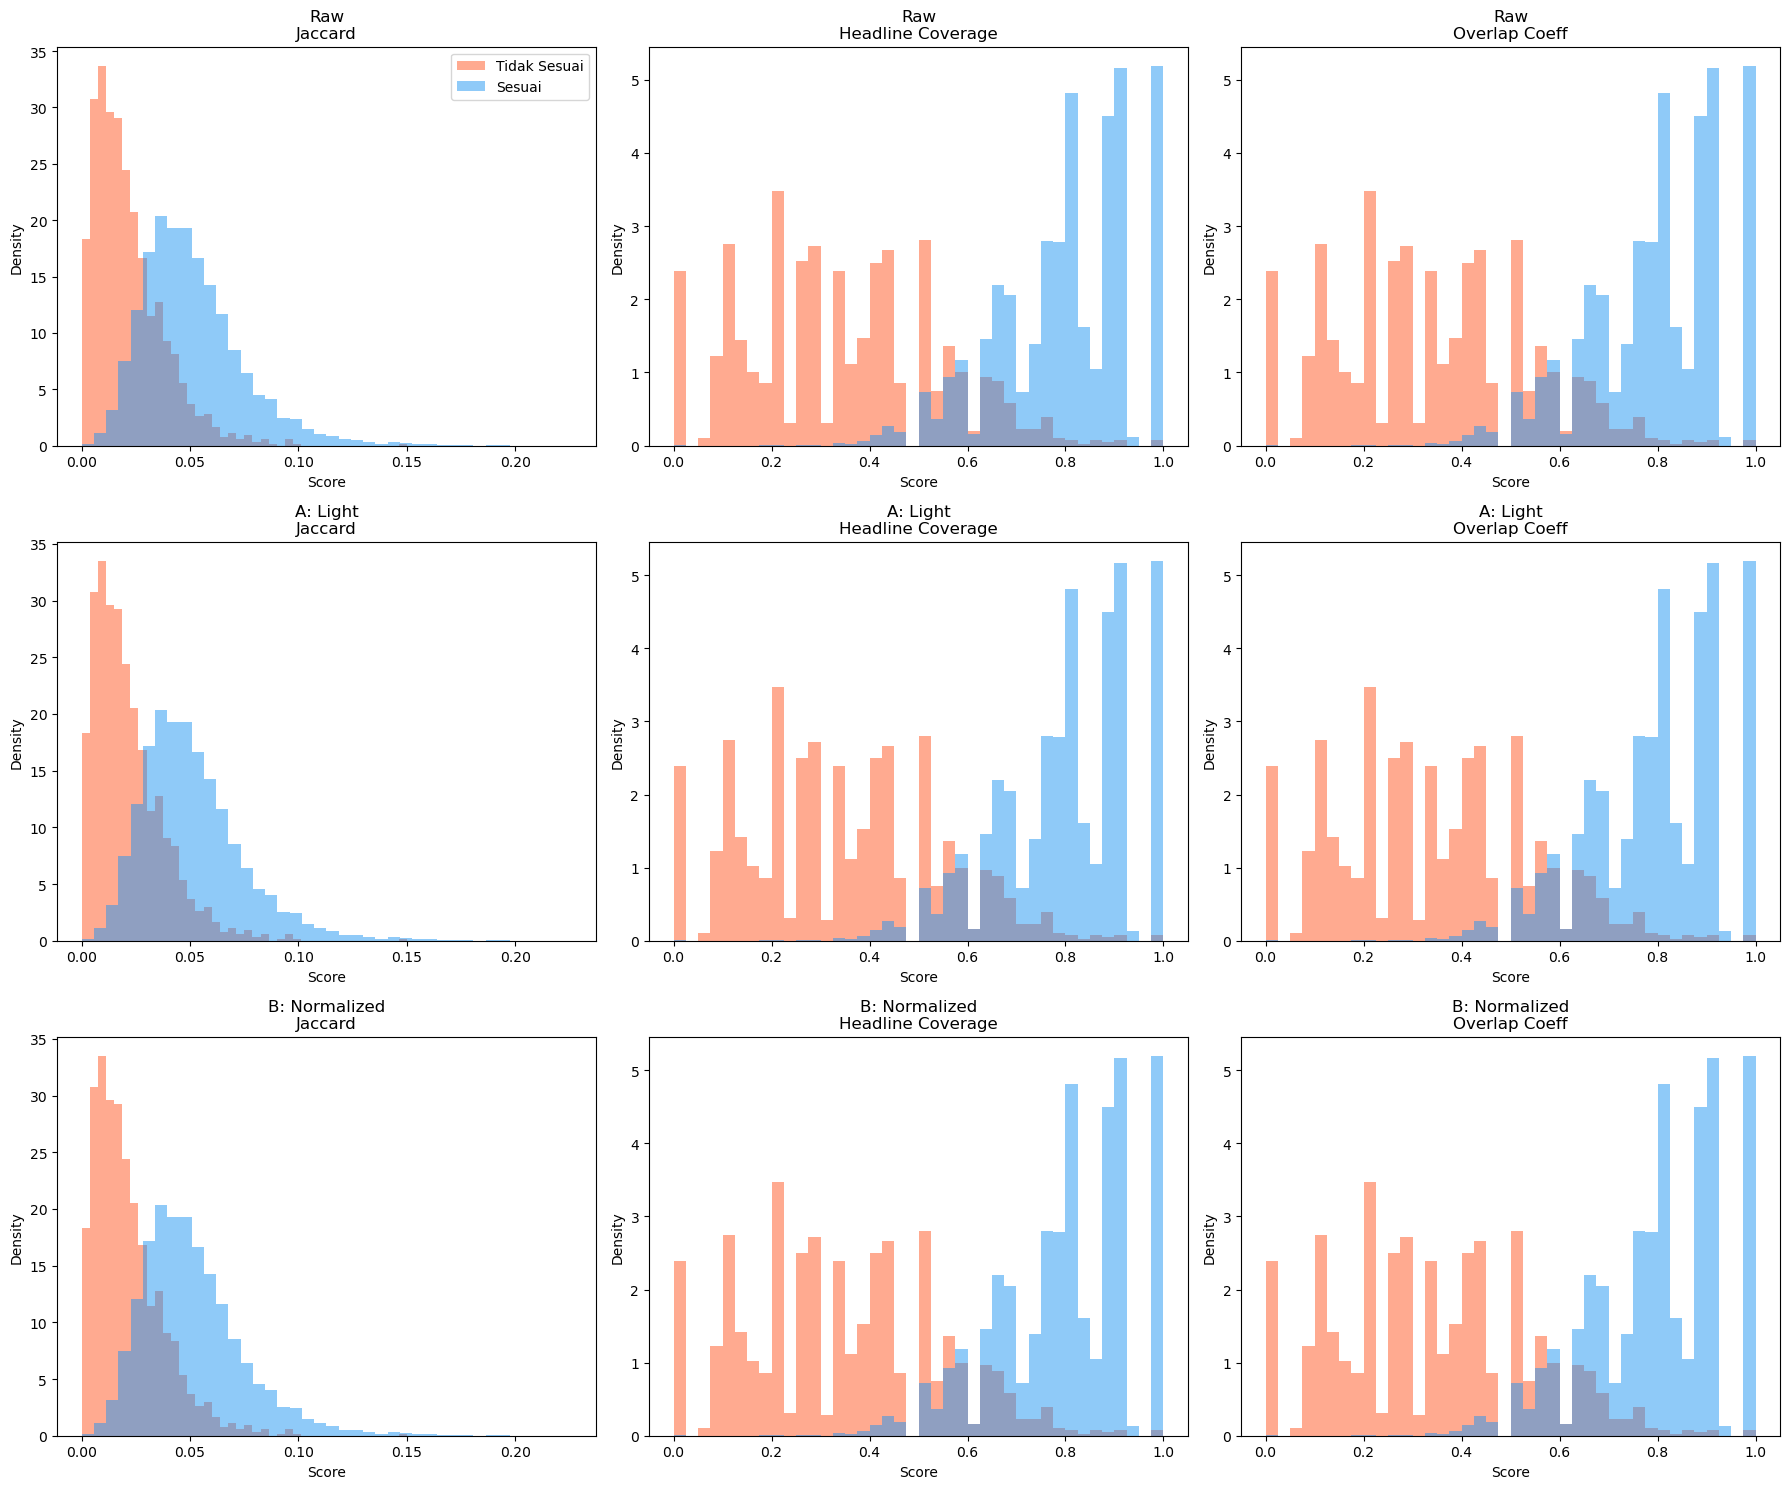


=== Lexical Overlap Separability ===
  Raw | jaccard: gap=0.0297 (Sesuai=0.0510, Tidak=0.0213)
  Raw | headline_coverage: gap=0.4594 (Sesuai=0.7982, Tidak=0.3389)
  Raw | overlap_coeff: gap=0.4594 (Sesuai=0.7982, Tidak=0.3389)
  A: Light | jaccard: gap=0.0297 (Sesuai=0.0511, Tidak=0.0213)
  A: Light | headline_coverage: gap=0.4593 (Sesuai=0.7984, Tidak=0.3391)
  A: Light | overlap_coeff: gap=0.4593 (Sesuai=0.7984, Tidak=0.3391)
  B: Normalized | jaccard: gap=0.0297 (Sesuai=0.0511, Tidak=0.0213)
  B: Normalized | headline_coverage: gap=0.4593 (Sesuai=0.7984, Tidak=0.3391)
  B: Normalized | overlap_coeff: gap=0.4593 (Sesuai=0.7984, Tidak=0.3391)


In [9]:
def lexical_overlap(headline, article):
    h_tokens = set(str(headline).lower().split())
    a_tokens = set(str(article).lower().split())
    intersection = h_tokens & a_tokens
    union = h_tokens | a_tokens
    jaccard = len(intersection) / len(union) if len(union) > 0 else 0
    coverage = len(intersection) / len(h_tokens) if len(h_tokens) > 0 else 0
    overlap_coeff = len(intersection) / min(len(h_tokens), len(a_tokens)) if min(len(h_tokens), len(a_tokens)) > 0 else 0
    return jaccard, coverage, overlap_coeff

# Define variants: (suffix, headline_col_name, article_col_name, display_name)
variants = [
    ('raw', headline_col, article_col, 'Raw'),
    ('clean_a', f'{headline_col}_clean_a', f'{article_col}_clean_a', 'A: Light'),
    ('clean_b', f'{headline_col}_clean_b', f'{article_col}_clean_b', 'B: Normalized'),
]
if f'{headline_col}_clean_c' in train.columns:
    variants.append(('clean_c', f'{headline_col}_clean_c', f'{article_col}_clean_c', 'C: Stemmed'))

metrics_list = ['jaccard', 'headline_coverage', 'overlap_coeff']
colors = {1: '#2196F3', 0: '#FF5722'}

# Compute overlap for each variant
for suffix, h_col, a_col, display_name in variants:
    print(f"\n=== Lexical Overlap: {display_name} ===")
    overlap_data = train.apply(lambda row: lexical_overlap(row[h_col], row[a_col]), axis=1)
    overlap_df = pd.DataFrame(overlap_data.tolist(), columns=metrics_list, index=train.index)
    for m in metrics_list:
        train[f'{m}_{suffix}'] = overlap_df[m]

    for metric in metrics_list:
        print(f"\n  {metric}:")
        for lbl in sorted(train[label_col].unique()):
            s = train[train[label_col] == lbl][f'{metric}_{suffix}']
            lbl_name = label_names.get(int(lbl), str(lbl))
            print(f"    {lbl_name}: mean={s.mean():.4f}, median={s.median():.4f}, std={s.std():.4f}")

# Visualization: grid of variant x metric
n_variants = len(variants)
fig, axes = plt.subplots(n_variants, 3, figsize=(18, 5 * n_variants))
if n_variants == 1:
    axes = axes.reshape(1, -1)

for row_idx, (suffix, h_col, a_col, display_name) in enumerate(variants):
    for col_idx, metric in enumerate(metrics_list):
        ax = axes[row_idx, col_idx]
        col_name = f'{metric}_{suffix}'
        for lbl in sorted(train[label_col].unique()):
            subset = train[train[label_col] == lbl][col_name]
            lbl_name = label_names.get(int(lbl), str(lbl))
            ax.hist(subset, bins=40, alpha=0.5, label=lbl_name, color=colors[int(lbl)], density=True)
        ax.set_title(f'{display_name}\n{metric.replace("_", " ").title()}')
        if row_idx == 0 and col_idx == 0:
            ax.legend()
        ax.set_xlabel('Score')
        ax.set_ylabel('Density')
plt.tight_layout()
plt.show()

# Separability score: |mean(Sesuai) - mean(TidakSesuai)| per variant+metric
print("\n=== Lexical Overlap Separability ===")
overlap_sep_rows = []
for suffix, h_col, a_col, display_name in variants:
    for metric in metrics_list:
        col_name = f'{metric}_{suffix}'
        mean_1 = train[train[label_col] == 1][col_name].mean()
        mean_0 = train[train[label_col] == 0][col_name].mean()
        std_1 = train[train[label_col] == 1][col_name].std()
        std_0 = train[train[label_col] == 0][col_name].std()
        gap = abs(mean_1 - mean_0)
        overlap_sep_rows.append({
            'variant': display_name,
            'metric': metric,
            'mean_Sesuai': round(mean_1, 4),
            'mean_TidakSesuai': round(mean_0, 4),
            'separation_gap': round(gap, 4),
            'std_Sesuai': round(std_1, 4),
            'std_TidakSesuai': round(std_0, 4),
            'source': 'lexical_overlap'
        })
        print(f"  {display_name} | {metric}: gap={gap:.4f} (Sesuai={mean_1:.4f}, Tidak={mean_0:.4f})")

Estimating runtime: 3 variants x 28800 documents
Each variant: TF-IDF fit(28800) + SVD(28800x10000) + cosine_sim(14400 pairs)
Total: ~9 operations. Proceeding...

=== LSA Similarity: Raw ===
  TF-IDF shape: (28800, 10000), LSA explained variance: 0.2249
  LSA cosine similarity per label:
    Tidak Sesuai: mean=0.2667, median=0.2114, std=0.2197
    Sesuai: mean=0.5163, median=0.5213, std=0.1897
  Separability gap: 0.2496

=== LSA Similarity: A: Light ===
  TF-IDF shape: (28800, 10000), LSA explained variance: 0.2249
  LSA cosine similarity per label:
    Tidak Sesuai: mean=0.2683, median=0.2168, std=0.2199
    Sesuai: mean=0.5182, median=0.5235, std=0.1894
  Separability gap: 0.2499

=== LSA Similarity: B: Normalized ===
  TF-IDF shape: (28800, 10000), LSA explained variance: 0.2249
  LSA cosine similarity per label:
    Tidak Sesuai: mean=0.2683, median=0.2168, std=0.2199
    Sesuai: mean=0.5182, median=0.5235, std=0.1894
  Separability gap: 0.2499



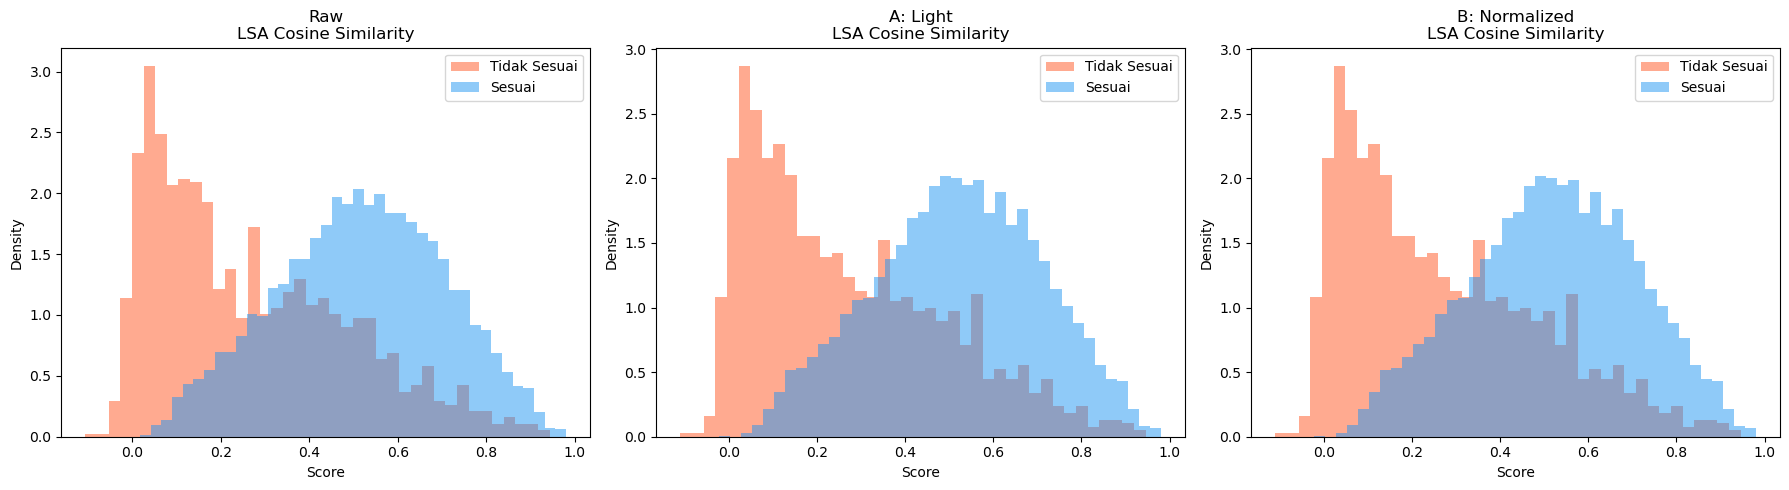

In [10]:
# Estimate runtime
n_train = len(train)
n_text = n_train * 2
print(f"Estimating runtime: {len(variants)} variants x {n_text} documents")
print(f"Each variant: TF-IDF fit({n_text}) + SVD({n_text}x10000) + cosine_sim({n_train} pairs)")
print(f"Total: ~{len(variants) * 3} operations. Proceeding...\n")

lsa_rows = []

for suffix, h_col, a_col, display_name in variants:
    print(f"=== LSA Similarity: {display_name} ===")

    # Combine all text for this variant
    all_text = pd.concat([train[h_col], train[a_col]]).astype(str)

    # TF-IDF + SVD
    tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
    tfidf_matrix = tfidf.fit_transform(all_text)

    n_components = 100
    svd = TruncatedSVD(n_components=n_components, random_state=SEED)
    lsa_matrix = svd.fit_transform(tfidf_matrix)
    explained_var = svd.explained_variance_ratio_.sum()
    print(f"  TF-IDF shape: {tfidf_matrix.shape}, LSA explained variance: {explained_var:.4f}")

    # Split back
    lsa_headline = lsa_matrix[:n_train]
    lsa_article = lsa_matrix[n_train:2*n_train]

    # Cosine similarity
    lsa_sim = np.array([
        cosine_similarity(lsa_headline[i:i+1], lsa_article[i:i+1])[0,0]
        for i in range(n_train)
    ])
    col_name = f'lsa_cosine_sim_{suffix}'
    train[col_name] = lsa_sim

    # Stats per label
    print(f"  LSA cosine similarity per label:")
    for lbl in sorted(train[label_col].unique()):
        s = train[train[label_col] == lbl][col_name]
        lbl_name = label_names.get(int(lbl), str(lbl))
        print(f"    {lbl_name}: mean={s.mean():.4f}, median={s.median():.4f}, std={s.std():.4f}")

    # Separability
    mean_1 = train[train[label_col] == 1][col_name].mean()
    mean_0 = train[train[label_col] == 0][col_name].mean()
    std_1 = train[train[label_col] == 1][col_name].std()
    std_0 = train[train[label_col] == 0][col_name].std()
    gap = abs(mean_1 - mean_0)
    lsa_rows.append({
        'variant': display_name,
        'metric': 'lsa_cosine_sim',
        'mean_Sesuai': round(mean_1, 4),
        'mean_TidakSesuai': round(mean_0, 4),
        'separation_gap': round(gap, 4),
        'std_Sesuai': round(std_1, 4),
        'std_TidakSesuai': round(std_0, 4),
        'source': 'lsa_similarity'
    })
    print(f"  Separability gap: {gap:.4f}\n")

# Visualization: overlay all variants for LSA
fig, axes = plt.subplots(1, len(variants), figsize=(6*len(variants), 5))
if len(variants) == 1:
    axes = [axes]
for ax, (suffix, h_col, a_col, display_name) in zip(axes, variants):
    col_name = f'lsa_cosine_sim_{suffix}'
    for lbl in sorted(train[label_col].unique()):
        subset = train[train[label_col] == lbl][col_name]
        lbl_name = label_names.get(int(lbl), str(lbl))
        ax.hist(subset, bins=40, alpha=0.5, label=lbl_name, color=colors[int(lbl)], density=True)
    ax.set_title(f'{display_name}\nLSA Cosine Similarity')
    ax.legend()
    ax.set_xlabel('Score')
    ax.set_ylabel('Density')
plt.tight_layout()
plt.show()

In [11]:
# Combine all separation scores
all_sep = pd.DataFrame(overlap_sep_rows + lsa_rows)
all_sep = all_sep.sort_values('separation_gap', ascending=False).reset_index(drop=True)

print("=" * 90)
print("  COMPARATIVE SEPARABILITY SUMMARY — Sorted by Separation Gap (descending)")
print("=" * 90)
print(all_sep.to_string(index=False))
print("=" * 90)

# Quick summary
print("\n=== TOP 5 Most Discriminative Features ===")
for i, row in all_sep.head(5).iterrows():
    print(f"  {row['source']:20s} | {row['variant']:15s} | {row['metric']:20s} | gap={row['separation_gap']:.4f}")

print("\n=== BEST VARIANT per SOURCE ===")
for src in all_sep['source'].unique():
    subset = all_sep[all_sep['source'] == src]
    best = subset.iloc[0]
    print(f"  {src:20s} → {best['variant']:15s} | gap={best['separation_gap']:.4f}")

print("\n=== RECOMMENDATIONS (for your review) ===")
best_overall = all_sep.iloc[0]
print(f"  Best overall: {best_overall['source']} + {best_overall['variant']} (gap={best_overall['separation_gap']:.4f})")
print(f"  Review the table above to decide:")
print(f"    1. Which preprocessing variant to use as default")
print(f"    2. Which feature set (lexical overlap / LSA / both) for baseline")
print(f"    3. Whether stopword removal helps or hurts discriminability")

  COMPARATIVE SEPARABILITY SUMMARY — Sorted by Separation Gap (descending)
      variant            metric  mean_Sesuai  mean_TidakSesuai  separation_gap  std_Sesuai  std_TidakSesuai          source
          Raw headline_coverage       0.7982            0.3389          0.4594      0.1363           0.1965 lexical_overlap
          Raw     overlap_coeff       0.7982            0.3389          0.4594      0.1363           0.1965 lexical_overlap
     A: Light     overlap_coeff       0.7984            0.3391          0.4593      0.1362           0.1965 lexical_overlap
     A: Light headline_coverage       0.7984            0.3391          0.4593      0.1362           0.1965 lexical_overlap
B: Normalized headline_coverage       0.7984            0.3391          0.4593      0.1362           0.1965 lexical_overlap
B: Normalized     overlap_coeff       0.7984            0.3391          0.4593      0.1362           0.1965 lexical_overlap
B: Normalized    lsa_cosine_sim       0.5182            0

In [12]:
# Convert comparison results to serializable format
comparison_summary = all_sep.to_dict(orient='records')

pipeline_config = {
    "pipeline_version": "v1",
    "created_at": datetime.now().isoformat(),
    "dataset": {
        "train_rows": int(len(train)),
        "test_rows": int(len(test)),
        "columns_discovered": {
            "headline": headline_col,
            "article": article_col,
            "label": label_col
        }
    },
    "steps": [
        {"step": "normalize_whitespace", "applied_to": [headline_col, article_col], "params": {"regex": r"\s+", "replacement": " "}},
        {"step": "remove_url", "applied_to": [headline_col, article_col], "params": {"pattern": "https?://|www\\."}},
        {"step": "remove_html", "applied_to": [headline_col, article_col], "params": {"pattern": "<[^>]+>"}},
        {"step": "remove_noise", "applied_to": [headline_col, article_col], "params": {"remove_email": True, "keep_punctuation": ".,;:!?%$()-/+"}},
        {"step": "lowercase", "applied_to": [headline_col, article_col], "params": {}},
        {"step": "stopword_removal", "applied_to": [headline_col, article_col], "params": {"source": "Sastrawi"}},
        {"step": "stemming", "applied_to": [headline_col, article_col], "params": {"source": "Sastrawi"}}
    ],
    "variants": {
        "A_light": ["normalize_whitespace", "remove_url", "remove_html", "remove_noise"],
        "B_normalized": ["normalize_whitespace", "remove_url", "remove_html", "remove_noise", "lowercase", "stopword_removal"],
        "C_stemmed": ["normalize_whitespace", "remove_url", "remove_html", "remove_noise", "lowercase", "stopword_removal", "stemming"]
    },
    "eda_comparison_summary": comparison_summary,
    "libraries_used": [
        "nltk (tokenization only — static resource, not pretrained)",
        "Sastrawi (stopword list + stemmer — rule-based, not pretrained)",
        "sklearn (TF-IDF, CountVectorizer, SVD — from scratch)",
        "wordcloud (visualization only)"
    ],
    "libraries_needed_pending_approval": [
        "rank_bm25 (untuk BM25 scoring di modeling session berikutnya)",
        "xgboost (untuk classifier di modeling session berikutnya)"
    ],
    "notes": {
        "pretrained_models_used": "NONE — all representations trained from scratch on competition data",
        "raw_text_preserved": True,
        "column_mapping": "Auto-discovered from CSV, not hardcoded",
        "outliers_handled": "Analyzed only, NOT removed",
        "eda_purpose": "Comparison table is OUTPUT ANALYSIS — feature/variant selection decided by user after review"
    }
}

# Save
output_path = '../data/processing/pipeline_config_v1.json'
os.makedirs(os.path.dirname(output_path), exist_ok=True)
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(pipeline_config, f, indent=2, ensure_ascii=False)
print(f"Pipeline config saved to: {output_path}")
print()
print(json.dumps(pipeline_config, indent=2, ensure_ascii=False))

Pipeline config saved to: ../data/processing/pipeline_config_v1.json

{
  "pipeline_version": "v1",
  "created_at": "2026-09-03T18:28:13.272954",
  "dataset": {
    "train_rows": 14400,
    "test_rows": 3600,
    "columns_discovered": {
      "headline": "title",
      "article": "content",
      "label": "label"
    }
  },
  "steps": [
    {
      "step": "normalize_whitespace",
      "applied_to": [
        "title",
        "content"
      ],
      "params": {
        "regex": "\\s+",
        "replacement": " "
      }
    },
    {
      "step": "remove_url",
      "applied_to": [
        "title",
        "content"
      ],
      "params": {
        "pattern": "https?://|www\\."
      }
    },
    {
      "step": "remove_html",
      "applied_to": [
        "title",
        "content"
      ],
      "params": {
        "pattern": "<[^>]+>"
      }
    },
    {
      "step": "remove_noise",
      "applied_to": [
        "title",
        "content"
      ],
      "params": {
        "rem